### Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb

import matplotlib.pyplot as plt
from matplotlib import rcParams

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV

### Data Preprocessing

In [2]:
df = pd.read_csv('2024_tracker.csv')
df = df[['Mood', 'Alcohol', 'Weed', 'Sex', 'Masturbation', 'Video Games']]

df.replace(to_replace = 'Y', value=1, inplace=True)
df.replace(to_replace = 'Y!', value=1, inplace=True)
df.replace(to_replace = 'N', value=0, inplace=True)

minmax = MinMaxScaler()

alcohol_X = df[['Alcohol']]
minmax.fit(alcohol_X)
df['alcohol_normalized'] = minmax.transform(alcohol_X)
df.drop(columns='Alcohol', inplace=True)

mood_X = df[['Mood']]
minmax.fit(mood_X)
df['mood_normalized'] = minmax.transform(mood_X)
df.drop(columns='Mood', inplace=True)

df.dropna(axis=0, inplace=True)
df.head()

,Weed,Sex,Masturbation,Video Games,alcohol_normalized,mood_normalized
0,1,0,0,1,0.000000,0.50
1,0,1,0,1,0.000000,0.75
2,0,0,1,1,0.000000,0.50
3,0,0,0,1,0.000000,0.50
4,1,0,1,1,0.285714,0.50


### Correlation Matrix

In [3]:
def corr_combined(df, file_path=None):
    rcParams['figure.figsize'] = 10,10
    plt.figure()
    numeric_bool_df = df.select_dtypes(include=[np.number, bool])
    corr_matrix = numeric_bool_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    ax = sb.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu')
    # plt.savefig(file_path)

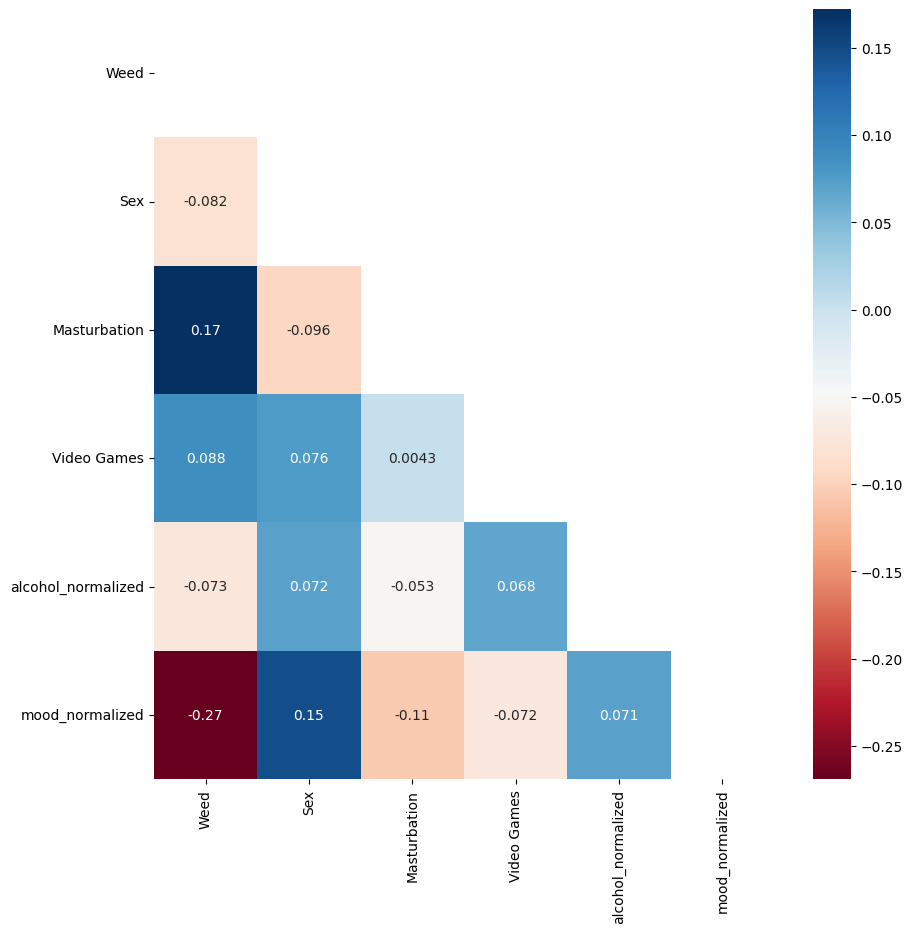

In [4]:
corr_combined(df)

### Decision Tree Regressor: Mood

In [5]:
data = df[[
    # 'alcohol_normalized',
    'Weed',
    'Sex',
    # 'Masturbation',
    # 'Video Games',
    'mood_normalized']] # Add predictor here
data.dropna(axis=0, inplace=True)

# data.info()

C:\Users\sfind\AppData\Local\Temp\ipykernel_23376\1775956796.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(axis=0, inplace=True)


[Text(0.5, 0.8333333333333334, 'Weed <= 0.5\nsquared_error = 0.035\nsamples = 292\nvalue = 0.527'),
 Text(0.25, 0.5, 'Sex <= 0.5\nsquared_error = 0.035\nsamples = 230\nvalue = 0.551'),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.035\nsamples = 202\nvalue = 0.542'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.024\nsamples = 28\nvalue = 0.616'),
 Text(0.75, 0.5, 'Sex <= 0.5\nsquared_error = 0.028\nsamples = 62\nvalue = 0.435'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.026\nsamples = 58\nvalue = 0.422'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.016\nsamples = 4\nvalue = 0.625')]

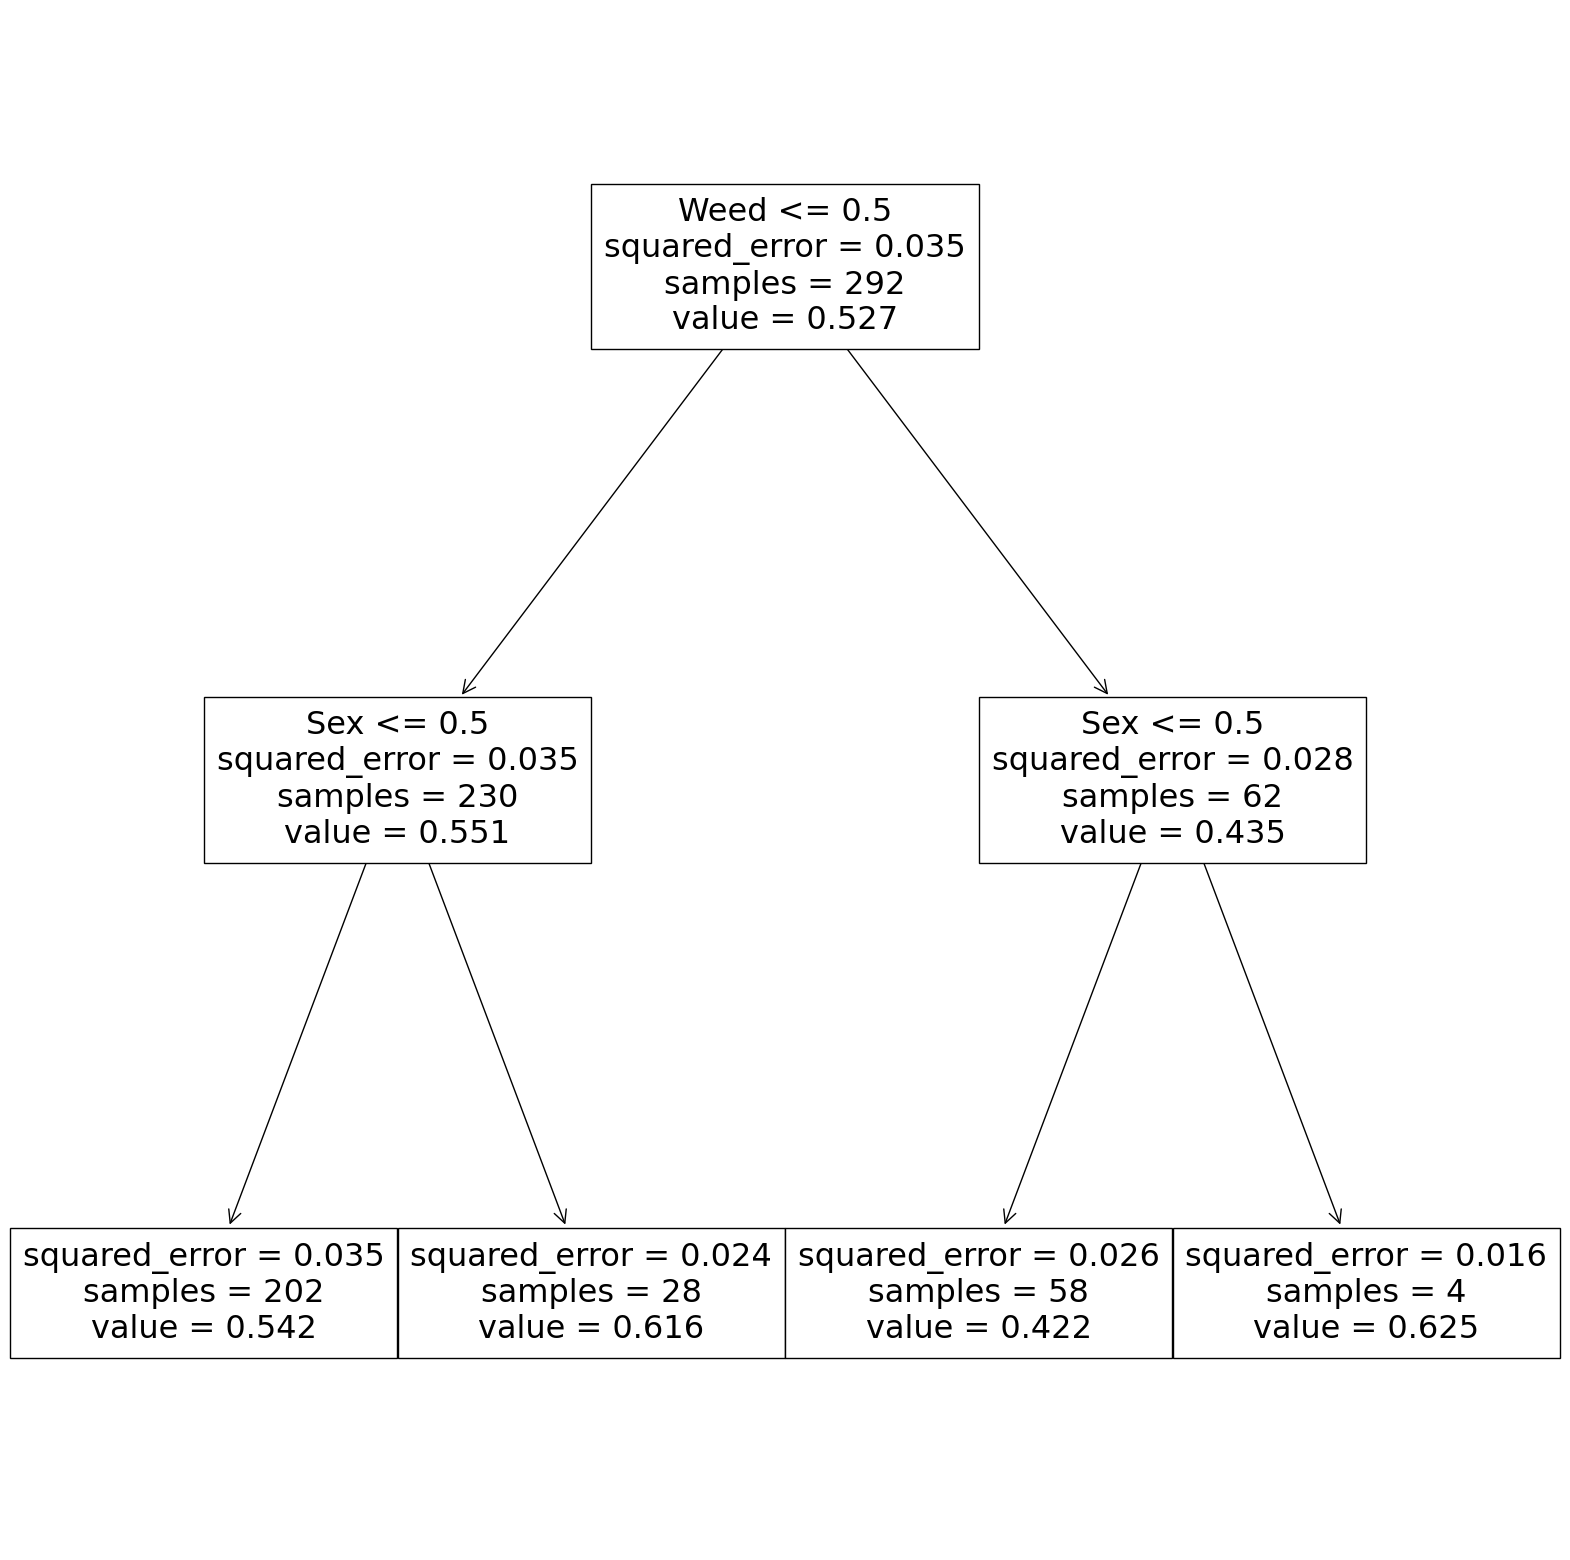

In [6]:
X = data.drop('mood_normalized', axis=1) # Modify to include your predictor
y = data['mood_normalized'] # Modify to include your predictor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # To be used in logistic/OLS

dt_best_model = DecisionTreeRegressor(random_state=42)
dt_best_model.fit(X_train, y_train)
y_pred = dt_best_model.predict(X_test)

fig,ax = plt.subplots(figsize=(20,20))
plot_tree(dt_best_model, feature_names = dt_best_model.feature_names_in_)

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

Mean Squared Error: 0.028999743161236036
Root Mean Squared Error: 0.17029310955301755
Mean Absolute Error: 0.1208805056214582
R2 Score: 0.06894778423786885


In [8]:
X_train = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train)
result = model.fit()
summary = result.summary()
print(summary)

Optimization terminated successfully.
         Current function value: 0.679094
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        mood_normalized   No. Observations:                  292
Model:                          Logit   Df Residuals:                      289
Method:                           MLE   Df Model:                            2
Date:                Wed, 01 Jan 2025   Pseudo R-squ.:                0.006106
Time:                        14:09:35   Log-Likelihood:                -198.30
converged:                       True   LL-Null:                       -199.51
Covariance Type:            nonrobust   LLR p-value:                    0.2957
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1606      0.140      1.146      0.252      -0.114       0.435
Weed          -0.4446      0.

### Decision Tree Regressor: Alcohol

In [9]:
data = df[[
    # 'mood_normalized',
    'Weed',
    'Sex',
    'Masturbation',
    'Video Games',
    'alcohol_normalized']] # Add predictor here
data.dropna(axis=0, inplace=True)

# data.info()

C:\Users\sfind\AppData\Local\Temp\ipykernel_23376\2522871875.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(axis=0, inplace=True)


[Text(0.5648148148148148, 0.9, 'Video Games <= 0.5\nsquared_error = 0.033\nsamples = 292\nvalue = 0.121'),
 Text(0.2962962962962963, 0.7, 'Weed <= 0.5\nsquared_error = 0.028\nsamples = 181\nvalue = 0.11'),
 Text(0.14814814814814814, 0.5, 'Masturbation <= 0.5\nsquared_error = 0.03\nsamples = 150\nvalue = 0.114'),
 Text(0.07407407407407407, 0.3, 'Sex <= 0.5\nsquared_error = 0.025\nsamples = 105\nvalue = 0.116'),
 Text(0.037037037037037035, 0.1, 'squared_error = 0.024\nsamples = 96\nvalue = 0.112'),
 Text(0.1111111111111111, 0.1, 'squared_error = 0.038\nsamples = 9\nvalue = 0.159'),
 Text(0.2222222222222222, 0.3, 'Sex <= 0.5\nsquared_error = 0.04\nsamples = 45\nvalue = 0.111'),
 Text(0.18518518518518517, 0.1, 'squared_error = 0.043\nsamples = 40\nvalue = 0.121'),
 Text(0.25925925925925924, 0.1, 'squared_error = 0.003\nsamples = 5\nvalue = 0.029'),
 Text(0.4444444444444444, 0.5, 'Masturbation <= 0.5\nsquared_error = 0.021\nsamples = 31\nvalue = 0.088'),
 Text(0.37037037037037035, 0.3, 'Sex

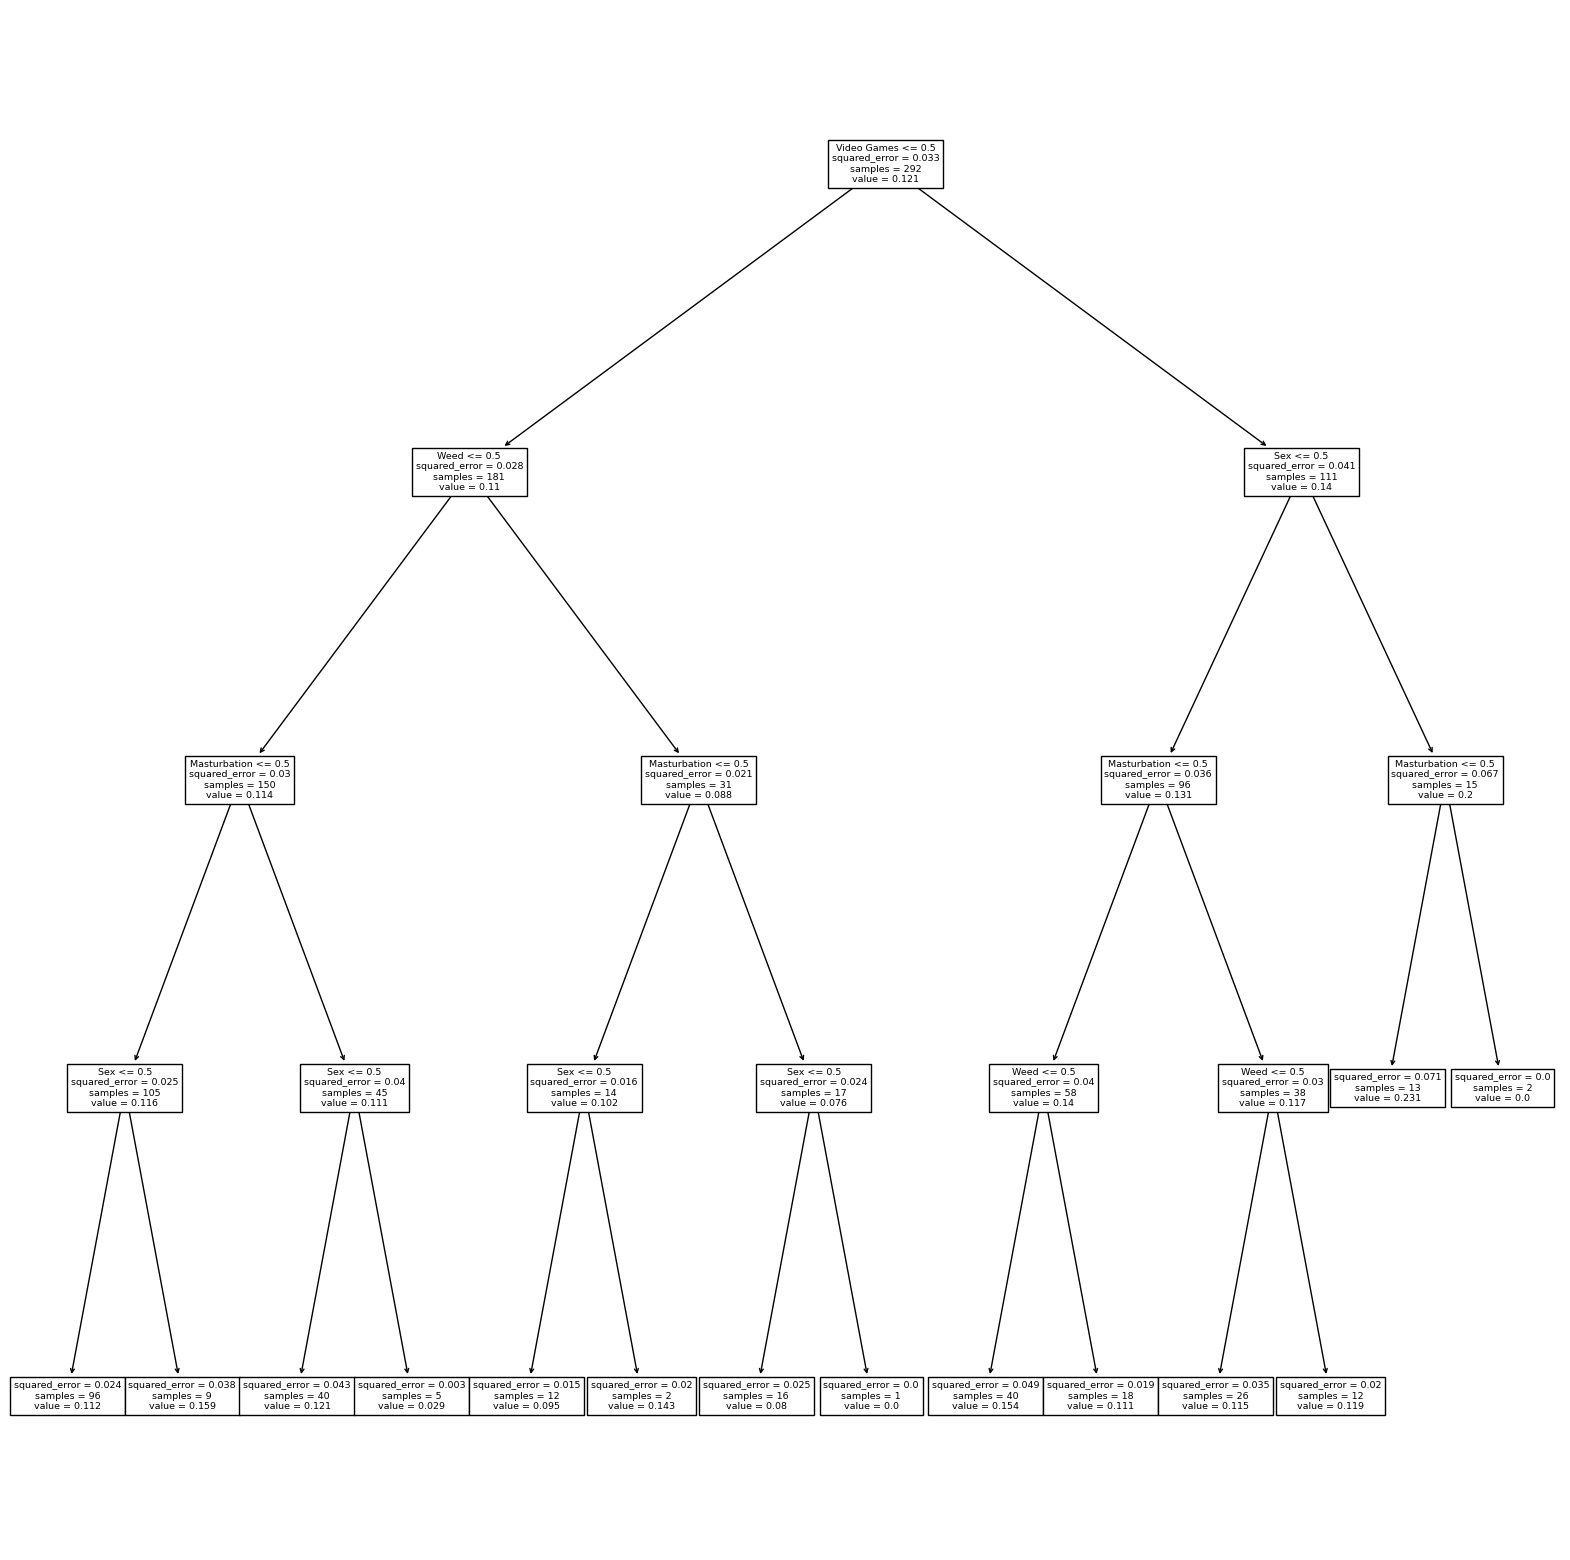

In [10]:
X = data.drop('alcohol_normalized', axis=1) # Modify to include your predictor
y = data['alcohol_normalized'] # Modify to include your predictor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # To be used in logistic/OLS

dt_best_model = DecisionTreeRegressor(random_state=42)
dt_best_model.fit(X_train, y_train)
y_pred = dt_best_model.predict(X_test)

fig,ax = plt.subplots(figsize=(20,20))
plot_tree(dt_best_model, feature_names = dt_best_model.feature_names_in_)

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

Mean Squared Error: 0.018747974680108952
Root Mean Squared Error: 0.13692324375396953
Mean Absolute Error: 0.11689900752400752
R2 Score: -0.09359381697077285


In [12]:
X_train = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train)
result = model.fit()
summary = result.summary()
print(summary)

Optimization terminated successfully.
         Current function value: 0.246086
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     alcohol_normalized   No. Observations:                  292
Model:                          Logit   Df Residuals:                      287
Method:                           MLE   Df Model:                            4
Date:                Wed, 01 Jan 2025   Pseudo R-squ.:                 -0.7990
Time:                        14:09:37   Log-Likelihood:                -71.857
converged:                       True   LL-Null:                       -39.942
Covariance Type:            nonrobust   LLR p-value:                     1.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.0061      0.280     -7.173      0.000      -2.554      -1.458
Weed            -0.2832